# **Statistical Analysis & Modelling**

## Objectives

- Apply statistical analysis to test hypotheses about smartphone usage and addiction
- Examine relationships between screen time, notifications, and addiction level
- Use statistical tests taught in the course to determine if relationships are significant

## Inputs
- Cleaned smartphone usage dataset from the previous notebook
- Python libraries: pandas, numpy, scipy, matplotlib

## Outputs
- Hypothesis test results
- Test statistics and p-values
- Short interpretations explaining whether each hypothesis is supported

## Additional Comments
- This notebook focuses on statistical testing of smartphone usage behaviour.
- Machine learning modelling will be performed in the next section.

# Section 4 - Hypothesis Tests

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
import pingouin as pg

In [72]:
df = pd.read_csv("../Data/Clean/clean_smartphone_usage.csv")
df.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
1,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
2,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
3,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe,1
4,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe,1


---

### Hypothesis 1 – Screen Time vs Addiction Level

H₀: There is no relationship between daily screen time and addiction level.
H₁: Higher daily screen time is associated with higher addiction levels.

Test: One-way ANOVA

In the context of the dataset: Users will be grouped into low, medium, and high daily screen time categories, and the test will evaluate whether the average addiction level differs across these groups. 



In [73]:
# Convert addiction level to numeric values
df['addiction_level_numeric'] = df['addiction_level'].map({
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
})

In [74]:
# Create screen time groups
df['screen_time_group'] = pd.cut(
    df['daily_screen_time_hours'],
    bins=[0, 4, 8, 12],
    labels=['Low Screen Time', 'Medium Screen Time', 'High Screen Time'],
    include_lowest=True
)

# Check group sizes
df['screen_time_group'].value_counts()

screen_time_group
High Screen Time      3344
Medium Screen Time    2735
Low Screen Time        602
Name: count, dtype: int64

In [75]:
anova_result = pg.anova(
    data=df,
    dv='addiction_level_numeric',
    between='screen_time_group',
    detailed=True
)

anova_result

,Source,SS,DF,MS,F,p_unc,np2
0,screen_time_group,802.380726,2,401.190363,944.651864,0.0,0.220525
1,Within,2836.123390,6678,0.424697,NaN,NaN,NaN


### What this code does

- The `addiction_level` variable was converted from categorical values (Mild, Moderate, Severe) into numeric values so that it can be used in statistical analysis.
- The variable `daily_screen_time_hours` was grouped into three categories using `pd.cut()`:
  - Low Screen Time (0–4 hours)
  - Medium Screen Time (4–8 hours)
  - High Screen Time (8–12 hours)
- A One-way ANOVA test was then performed using the `pingouin` library to examine whether the mean addiction level differs across the three screen time groups.
- The test compares the variation between groups (screen time categories) to the variation within groups to determine if the differences are statistically significant.



### Interpretation

The One-way ANOVA test produced an F-statistic of 944.65 with a p-value of 0.000.

Since the p-value is less than the significance level of 0.05, the null hypothesis is rejected.

This means that there is a statistically significant difference in addiction levels between the different screen time groups**.

The effect size (`np2 = 0.22`) indicates a moderate to large effect, suggesting that screen time explains a meaningful portion of the variation in smartphone addiction levels.



### In Context of the Dataset

The results suggest that daily smartphone screen time is strongly associated with smartphone addiction levels.

Users in the high screen time group (8–12 hours) are more likely to report higher addiction levels compared with those in the medium or low screen time groups.

This finding is consistent with expectations for smartphone usage behaviour, where increased exposure and engagement with mobile devices may contribute to stronger addictive patterns. The analysis therefore provides statistical evidence that higher screen time is linked to greater levels of smartphone addiction in the dataset.

---

### Hypothesis 2 – Notifications per Day and Addiction Level

H₀: There is no relationship between the number of notifications received per day and smartphone addiction level.

H₁: There is a relationship between the number of notifications received per day and smartphone addiction level.

Test: Pearson Correlation

In the context of the dataset: The analysis will examine whether users who receive more notifications per day tend to have higher levels of smartphone addiction.

In [76]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df['notifications_per_day'],
    df['addiction_level_numeric']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.010468418518531789
P-value: 0.39226085715833203


### What this code does

- The variable `notifications_per_day` represents how many notifications a user receives daily.
- The variable `addiction_level_numeric` represents smartphone addiction levels converted from categorical values (Mild, Moderate, Severe) into numeric values.
- Pearson correlation is used to measure the strength and direction of the relationship between notifications received and addiction level.
- The test produces a correlation coefficient and a p-value to determine statistical significance.

### Interpretation

The Pearson correlation test produced a correlation coefficient of -0.01 with a p-value of 0.392.

Since the p-value is greater than the significance level of 0.05, the null hypothesis cannot be rejected.

This means that there is no statistically significant relationship between the number of notifications received per day and smartphone addiction level in this dataset.

### In Context of the Dataset

The results suggest that receiving more notifications per day does not appear to be associated with higher smartphone addiction levels.

This indicates that smartphone addiction may be influenced more by other factors such as screen time, app usage, or behavioural patterns, rather than simply the number of notifications users receive.

---

## Hypothesis 3 – Gaming Usage and Addiction Level

H₀: There is no difference in average smartphone addiction levels between users who spend low time gaming and users who spend high time gaming.

H₁: There is a difference in average smartphone addiction levels between users who spend low time gaming and users who spend high time gaming.

Test: Independent Samples t-test

In the context of the dataset: Users will be divided into two groups based on their gaming hours (low gaming vs high gaming). The test will evaluate whether the average smartphone addiction level differs between these two groups.

In [77]:
# Create gaming groups
df['gaming_group'] = pd.cut(
    df['gaming_hours'],
    bins=[0, 2, 10],
    labels=['Low Gaming', 'High Gaming'],
    include_lowest=True
)

df['gaming_group'].value_counts()

gaming_group
High Gaming    3421
Low Gaming     3260
Name: count, dtype: int64

In [78]:
pg.ttest(
    df[df['gaming_group'] == 'Low Gaming']['addiction_level_numeric'],
    df[df['gaming_group'] == 'High Gaming']['addiction_level_numeric']
)

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,0.175149,6649.387837,two-sided,0.860968,"[-0.03, 0.04]",0.004289,0.053524,0.028


### What this code does

- The variable `gaming_hours` was grouped into two categories using `pd.cut()`:
  - Low Gaming (0–2 hours)
  - High Gaming (2–10 hours)
- This creates a new variable called `gaming_group` which divides users based on the amount of time they spend gaming.
- An independent samples t-test is then performed using the `pingouin` library.
- The test compares the average smartphone addiction level between the low gaming group and the high gaming group.
- The test outputs a t-statistic and a p-value which indicate whether the difference between the two groups is statistically significant.

### Interpretation

The independent samples t-test produced a t-statistic of 0.18 with a p-value of 0.861.

Since the p-value is greater than the significance level of 0.05, the null hypothesis cannot be rejected.

This means that there is no statistically significant difference in smartphone addiction levels between users who spend low time gaming and users who spend high time gaming.

### In Context of the Dataset

The results suggest that time spent gaming does not appear to be associated with differences in smartphone addiction levels in this dataset.

Users who spend more time gaming do not show significantly higher or lower addiction levels compared with users who spend less time gaming.

This indicates that smartphone addiction may be influenced more strongly by other behaviours such as screen time or social media usage rather than gaming activity alone.


---

# Section 5 - Machine Learning Model

### Problem definition

Predict smartphone addiction level using smartphone usage features such as daily screen time, social media hours, gaming hours, work/study hours, sleep hours, notifications per day and app opens per day.

### Why this is appropriate

Addiction level is a categorical variable, so a classification model is appropriate.

In the context of the dataset:

The model will use smartphone usage features to predict whether a user has a mild, moderate or severe level of smartphone addiction.

### Model choice

A Random Forest Classifier is used as a baseline model because it is suitable for classification problems, can handle multiple input features and works well on tabular data.

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [80]:
feature_cols = [
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day"
]

X = df[feature_cols]
y = df["addiction_level"]

X.head()

,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day
0,6.06,1.36,3.83,2.35,4.92,44,106
1,7.83,5.85,1.51,3.54,8.23,178,107
2,9.96,5.92,3.42,5.27,6.21,136,177
3,9.32,4.26,0.29,3.99,6.90,82,56
4,10.40,4.93,1.60,0.86,8.61,165,95


In [82]:
df["addiction_level"] = df["addiction_level"].replace({
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3
})

In [83]:
df["addiction_level"].head()

0    1
1    2
2    3
3    3
4    3
Name: addiction_level, dtype: object

In [84]:
X = df[feature_cols]
y = df["addiction_level"]

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5344, 7)
(1337, 7)


In [86]:
model = LinearRegression()

model.fit(X_train, y_train)

model

LinearRegression()

In [87]:
y_pred = model.predict(X_test)

In [88]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 0.3818941340275753
R² Score: 0.30718537927840683


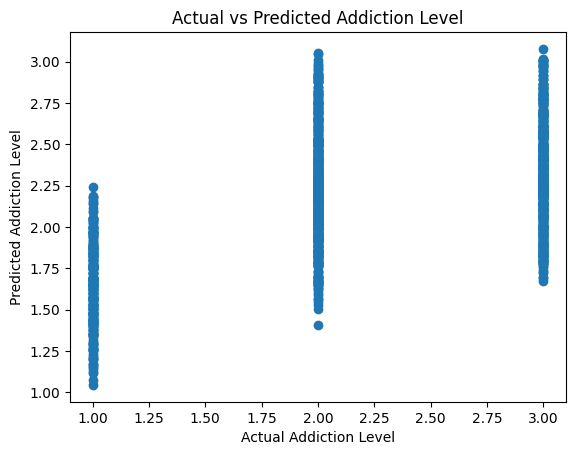

In [90]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Addiction Level")
plt.ylabel("Predicted Addiction Level")
plt.title("Actual vs Predicted Addiction Level")
plt.show()

---

# Section 6 - Key Findings, Limitations and Reflection

## Key Findings

### Exploratory Data Analysis




#### Hypothesis Test Results

**Hypothesis 1 – Energy and Song Popularity**

- 

**Hypothesis 2 – Acousticness and Song Popularity**

- 
**Hypothesis 3 – Tempo and Popular Songs**

- 


### Machine Learning Model Performance



The model achieved:

- Mean Squared Error (MSE) = 
- R² Score = 




### Interactive Dashboard




### Limitations



### Reflection




### Next Steps
